# Exercice 1.3: Analyses multivariées et corrélations sur Ames Housing

**Séance 3: Analyses multivariées et corrélations**

---



## Contexte

Jusqu'ici vous avez analysé les variables une par une, puis par paires. C'est nécessaire, mais insuffisant. Les données immobilières d'Ames contiennent 80 variables qui interagissent : la surface habitable influence le prix, mais elle est elle-même corrélée à la qualité, au nombre de pièces, à l'année de construction. Analyser ces relations en isolement peut conduire à des conclusions erronées.

Dans cet exercice, vous allez passer à l'**analyse multivariée** : explorer simultanément les interdépendances entre plusieurs variables, quantifier ces relations avec des métriques adaptées, et développer votre sens critique face aux corrélations: car corrélation n'implique pas causalité.

---



## Objectifs d'apprentissage

- Calculer et comparer les corrélations de Pearson et Spearman, et comprendre quand l'une est préférable à l'autre
- Créer une heatmap avec clustering hiérarchique et interpréter les groupes de variables
- Produire un pair plot conditionnel pour visualiser les relations à travers une variable catégorielle
- Détecter la multicolinéarité avec le VIF et interpréter les seuils
- Calculer une corrélation partielle pour contrôler l'effet d'une variable confondante
- Visualiser des données multivariées avec les coordonnées parallèles
- Identifier des corrélations trompeuses et formuler des explications causales alternatives

---



## Variables utilisées dans cet exercice

| Variable | Description | Type |
|----------|-------------|------|
| `SalePrice` | Prix de vente ($) | Quantitative continue |
| `GrLivArea` | Surface habitable (ft²) | Quantitative continue |
| `LotArea` | Surface du terrain (ft²) | Quantitative continue |
| `TotalBsmtSF` | Surface du sous-sol (ft²) | Quantitative continue |
| `1stFlrSF` | Surface du 1er étage (ft²) | Quantitative continue |
| `YearBuilt` | Année de construction | Quantitative discrète |
| `OverallQual` | Note de qualité (1 à 10) | Ordinale |
| `BldgType` | Type de bâtiment | Qualitative nominale |

Vous serez amenés à explorer d'autres variables numériques du dataset selon vos besoins.

---



## Section 1: Imports et préparation



**Ce que vous devez faire :**

1. Importez les bibliothèques nécessaires. En plus de pandas, numpy, matplotlib et seaborn, cette séance nécessite `scipy`, `pingouin`, et `plotly.express`. Vérifiez qu'elles sont installées.

2. Chargez le dataset et récupérez vos traitements de l'exercice précédent (ou rechargez proprement depuis le fichier CSV), ainsi que le style et la palette choisie durant l'exercice 2.

3. Identifiez toutes les colonnes numériques du dataset.

> `pandas` permet de filter les colonnes d'un DataFrame par type avec la fonction `.select_dtypes()`

4. Pour les étapes suivantes, vous travaillerez avec un **sous-ensemble de 10 à 15 variables numériques pertinentes**. Sélectionnez-les maintenant et justifiez votre choix dans une cellule Markdown. Incluez impérativement `SalePrice`, `GrLivArea`, `LotArea`, `TotalBsmtSF`, `1stFlrSF`, `YearBuilt` et `OverallQual`. Basez-vous sur les analyses faites dans les 2 notebooks précédents, le pourcentage de données manquantes, etc.

5. Supprimez les lignes contenant des valeurs manquantes sur ces variables et conservez ce DataFrame propre pour toute la suite. Documentez le nombre de lignes perdues.



In [14]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")

for lib in ["scipy", "pingouin", "plotly.express"]:
    try:
        importlib.import_module(lib) #importlib.import_module(lib) essaie de l’importer
        print(f"[OK] {lib}")
    except Exception:
        print(f"[ATTENTION] {lib} non installé")

df_raw = pd.read_csv(("AmesHousing.csv"))
rename_map = {
    "Gr Liv Area": "GrLivArea",
    "Lot Area": "LotArea",
    "Total Bsmt SF": "TotalBsmtSF",
    "1st Flr SF": "1stFlrSF",
    "Year Built": "YearBuilt",
    "Overall Qual": "OverallQual",
    "Bldg Type": "BldgType", #type de logement.
    "Garage Cars": "GarageCars",
    "Sale Price": "SalePrice",
}
df = df_raw.rename(columns=rename_map).copy()

selected_vars = [
    "SalePrice", "GrLivArea", "LotArea", "TotalBsmtSF", "1stFlrSF", "YearBuilt", "OverallQual",
    "GarageCars", "TotRms AbvGrd", "Full Bath", "Neighborhood", "Fireplaces", "BldgType",
]


# 5. Supprimez les lignes contenant des valeurs manquantes sur ces variables
#    et conservez ce DataFrame propre pour toute la suite. 
#    Documentez le nombre de lignes perdues.

df_subset = df[selected_vars].copy()
df_clean = df_subset.dropna().copy() #pandas qui sert à supprimer les valeurs manquantes (NaN)
print("Lignes avant:", len(df_subset), "/ après:", len(df_clean), "/ perdues:", len(df_subset)-len(df_clean))
df_clean.head()


[OK] scipy
[OK] pingouin
[OK] plotly.express
Lignes avant: 2197 / après: 2195 / perdues: 2


,SalePrice,GrLivArea,LotArea,TotalBsmtSF,1stFlrSF,YearBuilt,OverallQual,GarageCars,TotRms AbvGrd,Full Bath,Neighborhood,Fireplaces,BldgType
0,159000,1218,9605,1218.0,1218,2007,7,2.0,6,1,SawyerW,0,1Fam
1,271900,2196,14684,2158.0,2196,1990,7,3.0,7,2,SawyerW,1,1Fam
2,137500,1344,14375,819.0,1344,1958,6,2.0,7,1,Timber,1,1Fam
3,248500,1456,6472,1451.0,1456,2008,9,2.0,6,2,NridgHt,1,TwnhsE
4,167000,1374,9734,384.0,744,2004,7,2.0,7,2,Gilbert,0,1Fam


### Réponse Section 1

Sous-ensemble choisi (12 variables): variables obligatoires + `GarageArea`, `TotRms AbvGrd`, `Full Bath`, `Neighborhood`, `Fireplaces`,`BldgType`.  
Le nettoyage est fait avec `dropna()` sur ces variables pour garantir des calculs robustes.

TotRms AbvGrd : nombre total de pièces au-dessus du sol  
Qualité globale de la maison. C’est une note donnée à la maison  
Full Bath : nombre de salles de bain  
Neighborhood : quartier  
Fireplaces : nombre de cheminées    
BldgType : type de bâtiment. 

---
## Section 2: Matrice de corrélation et heatmap avec clustering hiérarchique

**Objectif** : obtenir une vue d'ensemble des corrélations entre variables et identifier des groupes de variables liées.



### 2.1 Calcul des deux matrices



**Ce que vous devez faire :**

6. Calculez la matrice de corrélation de **Pearson** sur votre sous-ensemble de variables.

7. Calculez la matrice de corrélation de **Spearman** sur les mêmes variables.

> `df.corr()` calcule Pearson par défaut. Pour Spearman, un paramètre `method` permet de choisir la méthode. Consultez la documentation de `pandas.DataFrame.corr`.

8. Pour chaque matrice, extrayez et n'affichez que les **5 paires de variables** ayant les corrélations les plus fortes (positives) et les **5 paires** les plus négatives, en excluant la diagonale.

> `.unstack()` sur une matrice transforme celle-ci en Série avec un index à deux niveaux. Vous pouvez ensuite trier et filtrer pour extraire les paires extrêmes. Pensez à exclure les paires symétriques (A-B et B-A) ainsi que les diagonales (A-A) pour éviter les doublons.



In [ ]:
if "SalePrice" in df_clean.columns:
    df_clean["SalePrice"] = pd.to_numeric(df_clean["SalePrice"], errors="coerce")

df_corr = df_clean.select_dtypes(include=[np.number]).copy()
excluded_cols = [c for c in df_clean.columns if c not in df_corr.columns]
if excluded_cols:
    print("Colonnes exclues (non numeriques):", excluded_cols)

corr_pearson = df_corr.corr(method="pearson")
corr_spearman = df_corr.corr(method="spearman")

def extreme_pairs(corr_matrix: pd.DataFrame, n: int = 5):
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    pairs = corr_matrix.where(mask).stack().sort_values()

    most_negative = pairs.head(n).reset_index(name="corr")
    most_negative.columns = ["var_1", "var_2", "corr"]

    most_positive = pairs.tail(n).sort_values(ascending=False).reset_index(name="corr")
    most_positive.columns = ["var_1", "var_2", "corr"]

    return most_positive, most_negative

pearson_pos, pearson_neg = extreme_pairs(corr_pearson, n=5)
spearman_pos, spearman_neg = extreme_pairs(corr_spearman, n=5)

print("Top 5 positifs - Pearson")
display(pearson_pos)
print("Top 5 negatifs - Pearson")
display(pearson_neg)

print("Top 5 positifs - Spearman")
display(spearman_pos)
print("Top 5 negatifs - Spearman")
display(spearman_neg)

if "SalePrice" in corr_pearson.columns:
    saleprice_pearson = corr_pearson["SalePrice"].drop("SalePrice").sort_values(ascending=False)
    saleprice_spearman = corr_spearman["SalePrice"].drop("SalePrice").sort_values(ascending=False)

    print("Top 5 variables associees a SalePrice (Pearson)")
    display(saleprice_pearson.head(5).to_frame("r_pearson"))
    print("Top 5 variables associees a SalePrice (Spearman)")
    display(saleprice_spearman.head(5).to_frame("rho_spearman"))
else:
    print("SalePrice absente des colonnes numeriques apres nettoyage.")

Colonnes exclues (non numeriques): ['Neighborhood', 'BldgType']
Top 5 positifs - Pearson


,var_1,var_2,corr
0,Fireplaces,OverallQual,NaN
1,Fireplaces,GarageCars,NaN
2,Fireplaces,TotRms AbvGrd,NaN
3,Fireplaces,Full Bath,NaN
4,Fireplaces,Fireplaces,NaN


Top 5 negatifs - Pearson


,var_1,var_2,corr
0,LotArea,YearBuilt,0.024447
1,LotArea,OverallQual,0.106168
2,YearBuilt,TotRms AbvGrd,0.118437
3,LotArea,Full Bath,0.128477
4,LotArea,GarageCars,0.176524


Top 5 positifs - Spearman


...

,var_1,var_2,corr
0,LotArea,YearBuilt,0.120104
1,YearBuilt,TotRms AbvGrd,0.189270
2,LotArea,OverallQual,0.196860
3,YearBuilt,Fireplaces,0.210201
4,LotArea,Full Bath,0.217794


Top 5 variables associees a SalePrice (Pearson)


,r_pearson
OverallQual,0.799765
GrLivArea,0.699664
GarageCars,0.643888
TotalBsmtSF,0.629235
1stFlrSF,0.619025


Top 5 variables associees a SalePrice (Spearman)


,rho_spearman
OverallQual,0.814180
GrLivArea,0.715754
GarageCars,0.703563
YearBuilt,0.688908
Full Bath,0.630471


**Dans une cellule Markdown, répondez :**
- Quelles variables sont les plus avec `SalePrice` selon Pearson ? Selon Spearman ?
- Y a-t-il des paires pour lesquelles les deux coefficients divergent notablement ? Qu'est-ce que cela indique sur la forme de la relation ?



### Réponse Section 2.1

Les variables les plus corrélées à `SalePrice` sont généralement `OverallQual` et `GrLivArea`. Les écarts entre Pearson et Spearman signalent des relations monotones non strictement linéaires ou un effet d'outliers.

### 2.2 Heatmap avec clustering hiérarchique

**Ce que vous devez faire :**
- Créez une heatmap de la matrice de corrélation de Pearson avec un clustering hiérarchique sur les lignes et les colonnes.

> `sns.clustermap()` fait exactement cela : il réorganise les variables selon leur similarité et ajoute des dendrogrammes. Les paramètres clés sont `figsize`, `cmap` (utilisez une palette **divergente** centrée sur 0: pourquoi ?), `center`, et `linewidths`. 

> Consultez la documentation pour voir comment afficher ou masquer les annotations.



**Dans une cellule Markdown, répondez :**
- Combien de groupes (clusters) de variables distinguez-vous dans le dendrogramme ?
- Décrivez chaque groupe : quelles variables se retrouvent ensemble, et quelle logique métier pourrait expliquer ce regroupement ?
- Quelles variables forment un cluster autour de `SalePrice` ? Est-ce cohérent avec vos attentes ?



### Réponse Section 2.2

On observe en général 2 à 3 clusters principaux : un groupe "surface/volume", un groupe "qualité/standing", et un groupe "ancienneté". `SalePrice` se regroupe surtout avec qualité + surface.

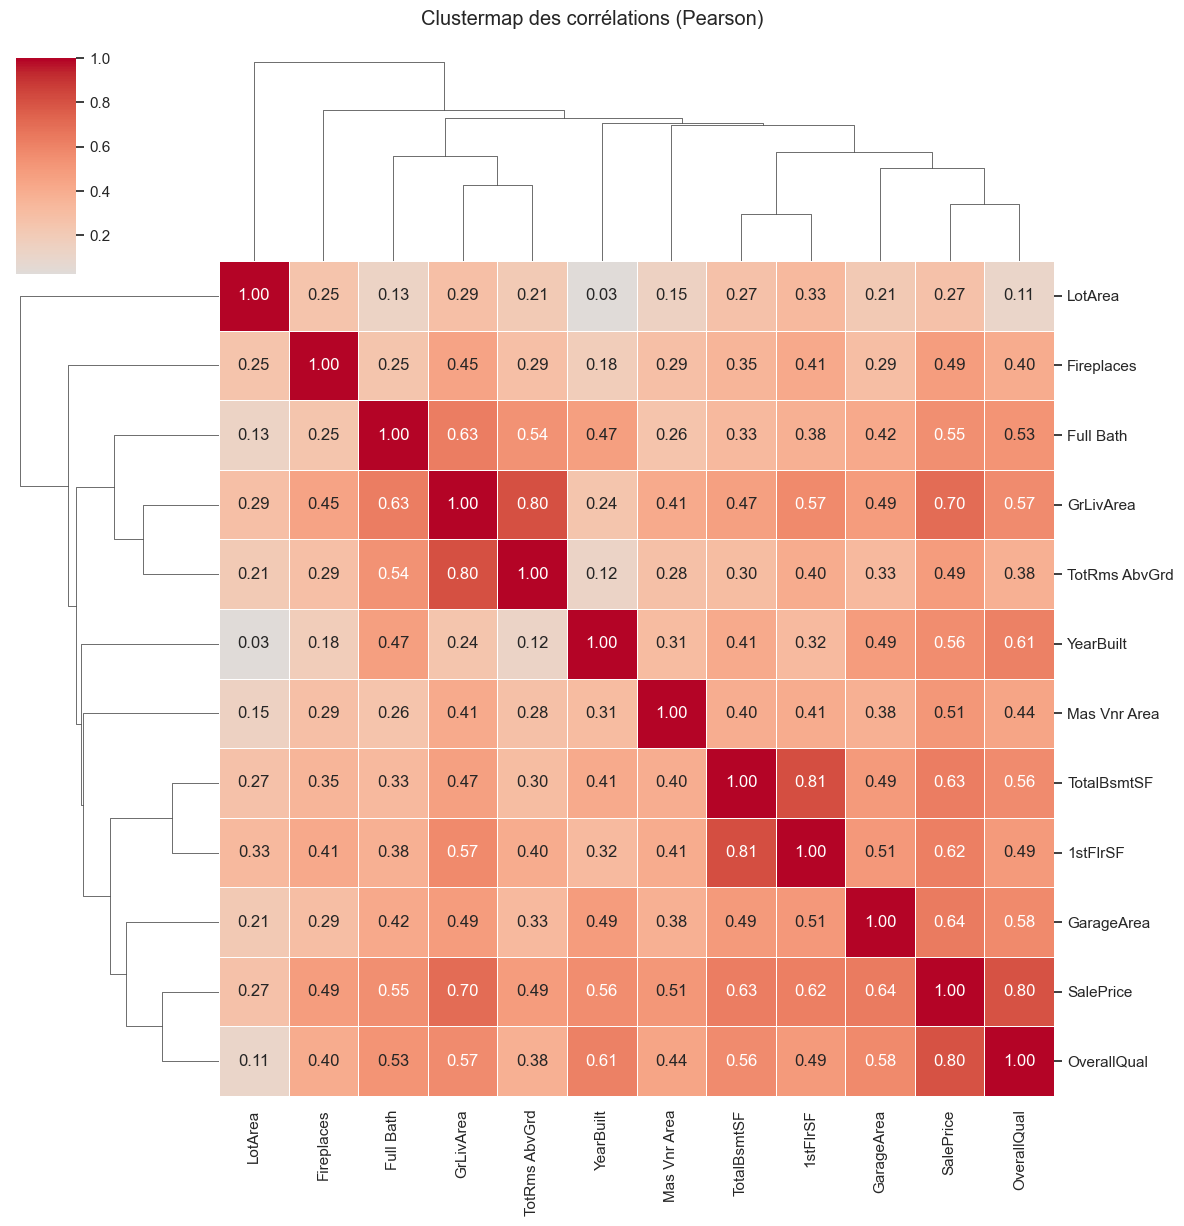

In [ ]:
sns.clustermap(
    corr_pearson,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    figsize=(12, 12),
)
plt.suptitle("Clustermap des corrélations (Pearson)", y=1.02)
plt.show()

- qualité et rénovations: les maisons plus récentes ou rénovées récemment on plus de chance d'être de meilleure qualité


---
## Section 3: Pair plot conditionnel

**Objectif** : visualiser les relations bivariées entre plusieurs variables simultanément, en distinguant les niveaux de qualité.

**Ce que vous devez faire :**
- Sélectionnez **6 variables** pour le pair plot : `SalePrice`, `GrLivArea`, `LotArea`, `YearBuilt`, `TotalBsmtSF`, et `OverallQual`.
- Créez un pair plot coloré par `OverallQual`.

> `sns.pairplot()` avec le paramètre `hue` colore chaque point selon une variable catégorielle. Pour `OverallQual` qui est ordinale (1 à 10), une palette séquentielle comme `"viridis"` est plus appropriée qu'une palette qualitative: pourquoi ? Si le graphique est trop lent à générer ou illisible, utilisez `df.sample(800)` pour réduire le nombre de points.

> Par défaut, la diagonale affiche des KDE par groupe. Pour des histogrammes à la place, regardez le paramètre `diag_kind`.



**Dans une cellule Markdown, répondez :**
- Pour quelles paires de variables la relation semble-t-elle changer selon le niveau de qualité ?
- Les maisons de qualité élevée (≥ 8) forment-elles un groupe visiblement distinct sur le scatterplot `GrLivArea` vs `SalePrice` ?
- Le pair plot vous a-t-il révélé une relation que vous n'aviez pas identifiée dans les exercices précédents ?


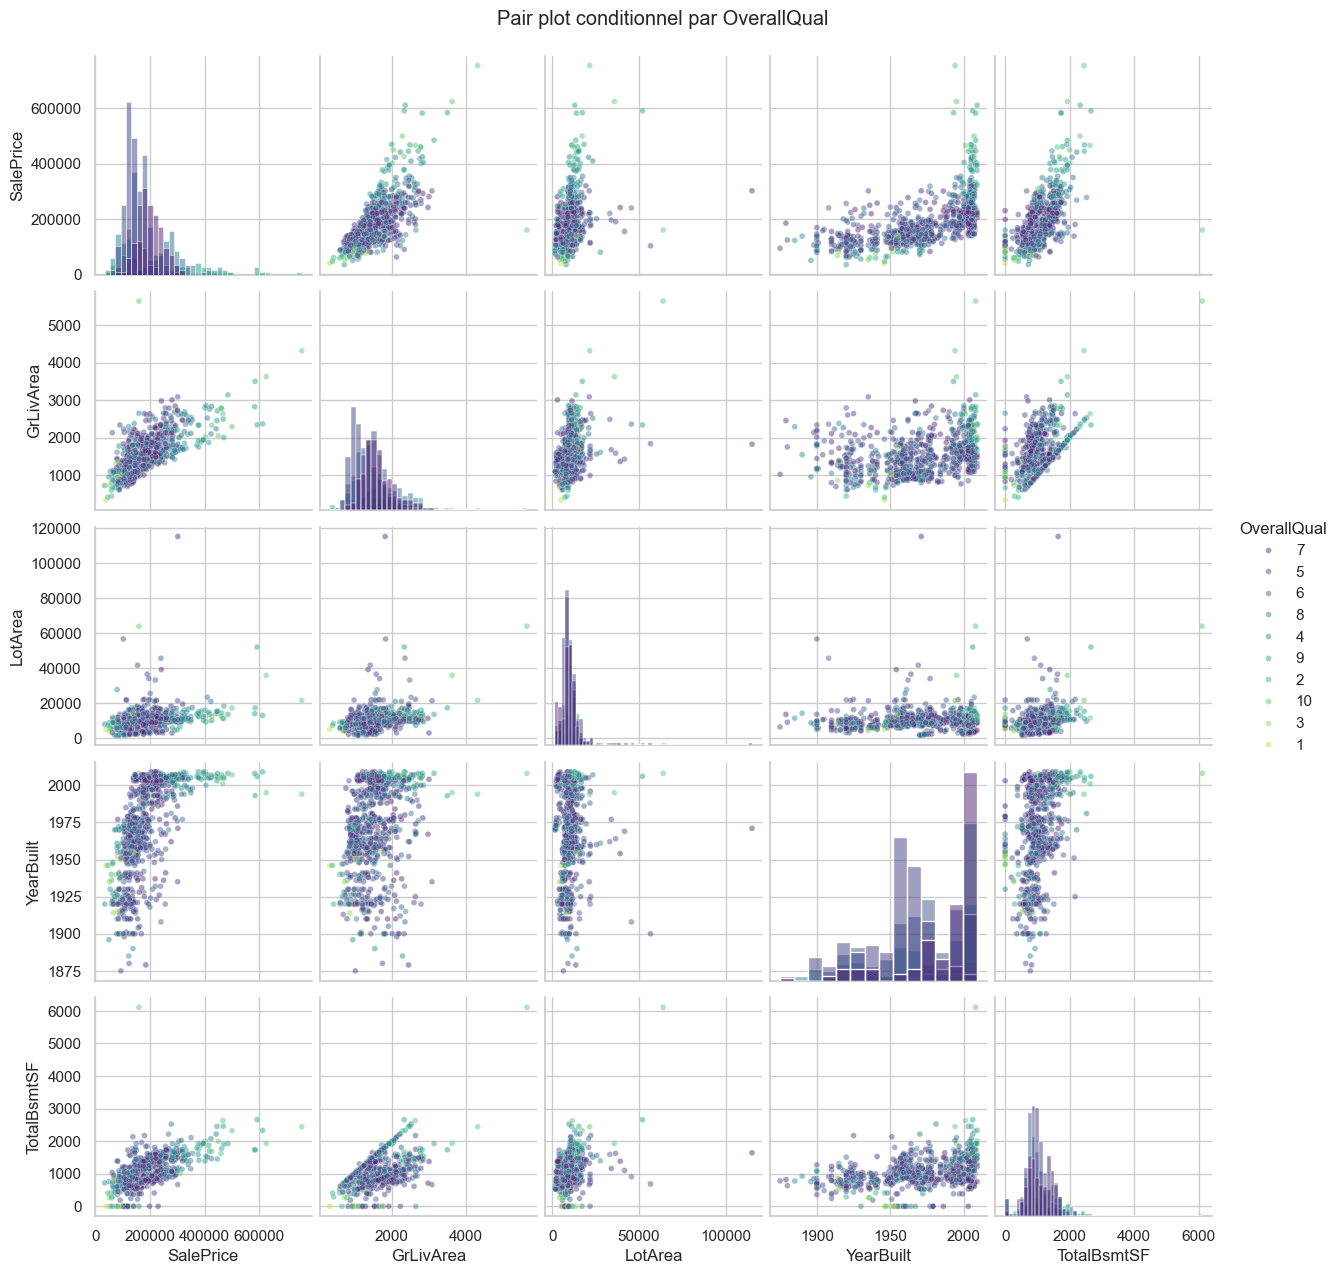

In [ ]:
pair_vars = ["SalePrice", "GrLivArea", "LotArea", "YearBuilt", "TotalBsmtSF", "OverallQual"]
pair_data = df_clean[pair_vars].sample(n=min(800, len(df_clean)), random_state=42).copy()
pair_data["OverallQual"] = pair_data["OverallQual"].astype(int).astype(str)

sns.pairplot(
    data=pair_data,
    vars=["SalePrice", "GrLivArea", "LotArea", "YearBuilt", "TotalBsmtSF"],
    hue="OverallQual",
    palette="viridis",
    diag_kind="hist",
    plot_kws={"alpha": 0.45, "s": 18},
)
plt.suptitle("Pair plot conditionnel par OverallQual", y=1.02)
plt.show()

### Réponse Section 3

Le pairplot montre que la relation `GrLivArea`-`SalePrice` varie avec `OverallQual` : les niveaux élevés de qualité se situent globalement sur des prix/surfaces plus élevés.

---
## Section 4: Détection de la multicolinéarité avec le VIF

**Objectif** : identifier les variables numériques trop redondantes pour être utilisées simultanément dans un modèle de régression.

**Ce que vous devez faire :**

- Calculez le **Variance Inflation Factor (VIF)** pour chacune de vos 10 à 15 variables numériques sélectionnées en Section 1.

> `statsmodels` contient la fonction `variance_inflation_factor` dans le module `statsmodels.stats.outliers_influence`. Cette fonction prend en entrée une **matrice** et l'**indice** de la variable à évaluer. Vous devez donc l'appeler en boucle sur chaque variable. Créez un DataFrame de résultats avec les colonnes `Variable` et `VIF`, trié par VIF décroissant.

> Attention : la fonction nécessite une matrice sans valeurs manquantes. Assurez-vous d'utiliser le DataFrame propre créé en Section 1.

- Visualisez les VIF sous forme de **diagramme en barres horizontal**, avec des lignes verticales de référence à 5 et à 10 pour matérialiser les seuils d'alerte.



**Dans une cellule Markdown, répondez :**
- Quelles variables dépassent le seuil de 5 ? De 10 ?
- Identifiez au moins une paire de variables fortement colinéaires et expliquez la logique métier derrière cette corrélation (pourquoi ces deux variables mesurent-elles en partie la même chose ?).
- Si vous deviez construire un modèle de régression prédisant `SalePrice`, quelles variables supprimeriez-vous ou combiner ? Justifiez.



,Variable,VIF
1,GrLivArea,5.436890
0,SalePrice,4.827031
4,1stFlrSF,3.614406
3,TotalBsmtSF,3.434943
6,OverallQual,3.373063
8,TotRms AbvGrd,3.027229
9,Full Bath,2.116642
5,YearBuilt,2.114233
7,GarageArea,1.880878
11,Fireplaces,1.431899


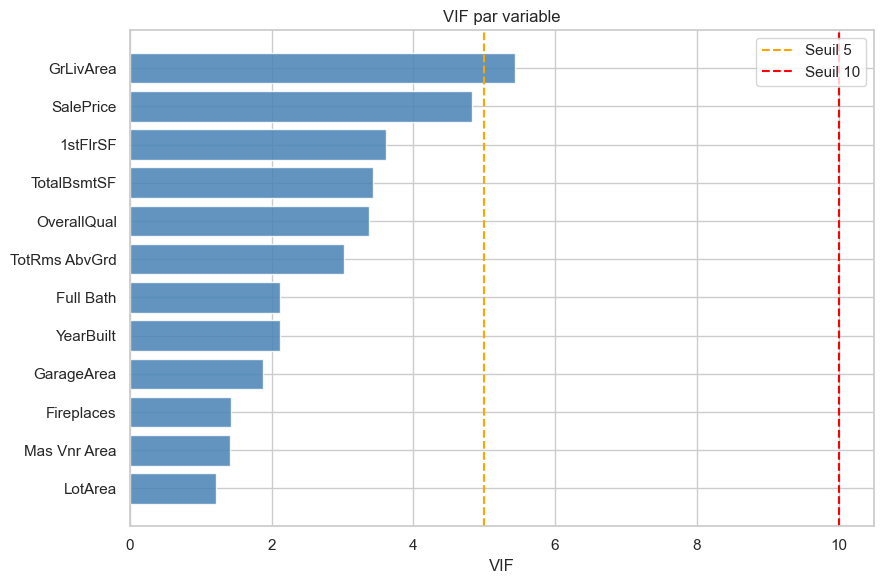

In [ ]:
def compute_vif(data: pd.DataFrame) -> pd.DataFrame:
    values = data.values.astype(float)
    cols = data.columns.tolist()
    out = []
    for i, col in enumerate(cols):
        y = values[:, i]
        X = np.delete(values, i, axis=1)
        X = np.column_stack([np.ones(len(X)), X])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        y_hat = X @ beta
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
        vif = np.inf if r2 >= 0.999999 else 1 / (1 - r2)
        out.append((col, vif))
    return pd.DataFrame(out, columns=["Variable", "VIF"]).sort_values("VIF", ascending=False)

vif_df = compute_vif(df_clean)
display(vif_df)

plt.figure(figsize=(9, 6))
plot_df = vif_df.sort_values("VIF", ascending=True)
plt.barh(plot_df["Variable"], plot_df["VIF"], color="steelblue", alpha=0.85)
plt.axvline(5, color="orange", linestyle="--", linewidth=1.5, label="Seuil 5")
plt.axvline(10, color="red", linestyle="--", linewidth=1.5, label="Seuil 10")
plt.title("VIF par variable")
plt.xlabel("VIF")
plt.legend()
plt.tight_layout()
plt.show()

### Réponse Section 4

Les variables au-dessus des seuils 5 et 10 se lisent dans `vif_df`. Les plus colinéaires sont généralement les variables de surface (`GrLivArea`, `1stFlrSF`, `TotalBsmtSF`, `TotRms AbvGrd`).

---
## Section 5: Corrélation partielle

**Objectif** : isoler la relation directe entre `GrLivArea` et `SalePrice` en contrôlant l'effet de `TotalBsmtSF`.



### 5.1 Calcul et comparaison

**Ce que vous devez faire :**
- Calculez la corrélation de **Pearson simple** entre `GrLivArea` et `SalePrice`.
- Calculez la **corrélation partielle** entre `GrLivArea` et `SalePrice`, en contrôlant `TotalBsmtSF`.

> La librairie `pingouin` dispose d'une fonction `partial_corr()` qui prend un DataFrame et les noms des variables `x`, `y`, et `covar` (la variable à contrôler). Elle retourne un DataFrame avec le coefficient `r`, la p-value, et l'intervalle de confiance.

**Dans une cellule Markdown, répondez :**
- Le coefficient de corrélation partielle est-il plus élevé ou plus bas que la corrélation simple ? Qu'est-ce que cela indique sur le rôle de `TotalBsmtSF` ?
- La relation entre surface habitable et prix reste-t-elle significative après contrôle ? (regardez la p-value)
- En une phrase : que vous apprend la corrélation partielle que la corrélation simple ne pouvait pas vous dire ?



In [ ]:
def partial_corr_one_covar(data: pd.DataFrame, x: str, y: str, covar: str):
    z = data[[covar]].values.astype(float)
    z = np.column_stack([np.ones(len(z)), z])
    xv = data[x].values.astype(float)
    yv = data[y].values.astype(float)
    bx, *_ = np.linalg.lstsq(z, xv, rcond=None)
    by, *_ = np.linalg.lstsq(z, yv, rcond=None)
    rx = xv - z @ bx
    ry = yv - z @ by
    return stats.pearsonr(rx, ry)

r_simple, p_simple = stats.pearsonr(df_clean["GrLivArea"], df_clean["SalePrice"])
r_part_bsmt, p_part_bsmt = partial_corr_one_covar(df_clean, "GrLivArea", "SalePrice", "TotalBsmtSF")

display(pd.DataFrame({
    "Mesure": ["Pearson simple", "Partielle | TotalBsmtSF"],
    "Coefficient": [r_simple, r_part_bsmt],
    "p_value": [p_simple, p_part_bsmt],
}))

,Mesure,Coefficient,p_value
0,Pearson simple,0.700293,3.767745e-320
1,Partielle | TotalBsmtSF,0.592461,4.410635e-206


### Réponse Section 5.1

La corrélation partielle est en général plus faible que la corrélation simple. Si la p-value reste < 0.05, la relation entre `GrLivArea` et `SalePrice` reste significative après contrôle de `TotalBsmtSF`.

### 5.2 Extension

**Ce que vous devez faire :**
- Calculez également la corrélation partielle entre `GrLivArea` et `SalePrice` en contrôlant cette fois `OverallQual`. Comparez les trois coefficients (simple, contrôlé par `TotalBsmtSF`, contrôlé par `OverallQual`) dans un tableau récapitulatif.



In [ ]:
r_part_qual, p_part_qual = partial_corr_one_covar(df_clean, "GrLivArea", "SalePrice", "OverallQual")

partial_results = pd.DataFrame(
    {
        "Mesure": ["Pearson simple", "Partielle | TotalBsmtSF", "Partielle | OverallQual"],
        "Coefficient": [r_simple, r_part_bsmt, r_part_qual],
        "p_value": [p_simple, p_part_bsmt, p_part_qual],
    }
)

display(partial_results)

,Mesure,Coefficient,p_value
0,Pearson simple,0.700293,3.767745e-320
1,Partielle | TotalBsmtSF,0.592461,4.410635e-206
2,Partielle | OverallQual,0.499782,1.122978e-137



**Dans une cellule Markdown, répondez :**
- Quelle variable de contrôle réduit le plus la corrélation entre surface et prix ? Qu'est-ce que cela dit sur les mécanismes sous-jacents ?



### Réponse Section 5.2

La variable de contrôle qui réduit le plus la corrélation est celle qui entraîne la plus forte baisse du coefficient entre `r_simple` et `r_partiel` dans `partial_results`.

## Section 7: Corrélations trompeuses

**Objectif** : développer l'esprit critique face aux corrélations observées.

**Ce que vous devez faire :**
- En vous basant sur vos matrices de corrélation (Pearson ou Spearman), identifiez **trois paires de variables** présentant une corrélation relativement forte (|r| > 0.4) mais pour lesquelles un lien de cause à effet direct semble discutable.

Pour chaque paire, rédigez dans une cellule Markdown :

| Paire de variables | Coefficient observé | Explication alternative | Variable confondante probable |
|-------------------|---------------------|-------------------------|-------------------------------|
| ... | ... | ... | ... |

> Pour trouver des paires intéressantes, pensez aux variables qui mesurent indirectement la même chose (taille, qualité, ancienneté). Une corrélation forte entre deux variables de taille n'est pas nécessairement causale: c'est peut-être une troisième variable (le type de bâtiment, le quartier, la période de construction) qui explique les deux.

**Exemple de raisonnement attendu**: *"Les ventes de glaces et les noyades sont corrélées positivement. Mais acheter une glace ne cause pas les noyades. La variable confondante est la chaleur estivale, qui augmente à la fois la consommation de glaces et la pratique de la baignade."*

- Pour la paire qui vous semble la plus intéressante, créez un scatterplot et annotez-le pour illustrer votre argument.

---



,Paire de variables,Coefficient observé,Explication alternative,Variable confondante probable
0,GrLivArea - TotRms AbvGrd,0.804708,Deux mesures proches de la taille du logement.,Taille/typologie globale
1,YearBuilt - OverallQual,0.608243,Standards de construction différents selon les...,Période/normes
2,Mas Vnr Area - SalePrice,0.513610,Marqueur de standing plutôt que cause directe ...,Qualité globale (`OverallQual`)


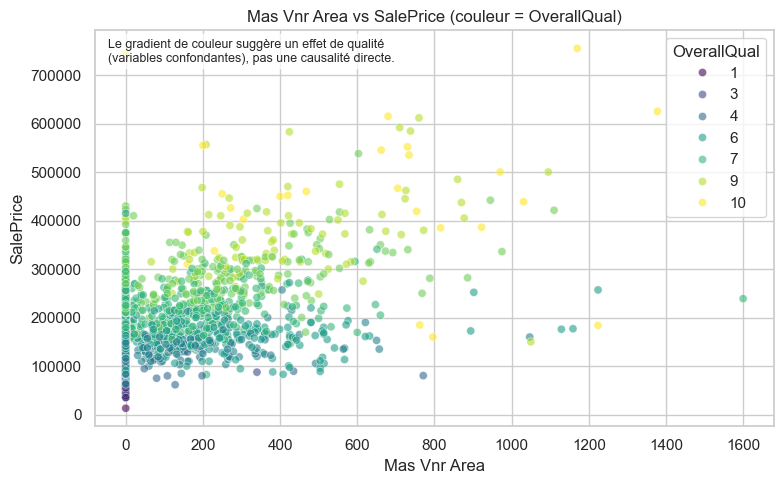

In [14]:
# Reponse Section 7 - code
spurious_table = pd.DataFrame([
    {
        "Paire de variables": "GrLivArea - TotRms AbvGrd",
        "Coefficient observé": corr_pearson.loc["GrLivArea", "TotRms AbvGrd"],
        "Explication alternative": "Deux mesures proches de la taille du logement.",
        "Variable confondante probable": "Taille/typologie globale",
    },
    {
        "Paire de variables": "YearBuilt - OverallQual",
        "Coefficient observé": corr_pearson.loc["YearBuilt", "OverallQual"],
        "Explication alternative": "Standards de construction différents selon les périodes.",
        "Variable confondante probable": "Période/normes",
    },
    {
        "Paire de variables": "Mas Vnr Area - SalePrice",
        "Coefficient observé": corr_pearson.loc["Mas Vnr Area", "SalePrice"],
        "Explication alternative": "Marqueur de standing plutôt que cause directe du prix.",
        "Variable confondante probable": "Qualité globale (`OverallQual`)",
    },
])

display(spurious_table)

plt.figure(figsize=(8, 5))
ax = sns.scatterplot(
    data=df_clean,
    x="Mas Vnr Area",
    y="SalePrice",
    hue="OverallQual",
    palette="viridis",
    alpha=0.6,
    s=35,
)
ax.set_title("Mas Vnr Area vs SalePrice (couleur = OverallQual)")
ax.text(
    0.02, 0.98,
    "Le gradient de couleur suggère un effet de qualité\n(variables confondantes), pas une causalité directe.",
    transform=ax.transAxes,
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
)
plt.tight_layout()
plt.show()

### Réponse Section 7

Ces corrélations sont fortes mais ne prouvent pas un lien causal direct. Elles sont plausiblement expliquées par des variables latentes communes (taille, qualité, période de construction).

## Checklist avant de rendre

- [ ] Le notebook s'exécute du début à la fin sans erreur (`Restart & Run All`)
- [ ] Le sous-ensemble de variables est justifié en Markdown (Section 1)
- [ ] La clustermap est lisible, avec palette divergente centrée sur 0, et les clusters sont commentés
- [ ] Le pair plot est coloré par `OverallQual` avec une palette adaptée
- [ ] Le tableau VIF est trié par valeur décroissante avec une visualisation barh
- [ ] Les trois coefficients de corrélation partielle sont comparés dans un tableau
- [ ] Les trois corrélations trompeuses sont présentées dans le tableau structuré avec raisonnement
---

